### Modelos para generación de video

In [1]:
# modelos: https://huggingface.co/models?other=diffusers%3AStableVideoDiffusionPipeline

In [2]:
from diffusers import StableVideoDiffusionPipeline
import torch

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"DEVICE: {DEVICE}")

modelo = StableVideoDiffusionPipeline.from_pretrained(
    "stabilityai/stable-video-diffusion-img2vid",
    dtype=torch.float16 if DEVICE in ("cuda", "mps") else torch.float32,
    use_safetensors=True,
    low_cpu_mem_usage=True,
    variant="fp16"
).to(DEVICE)

/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: mps


Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 23.30it/s]


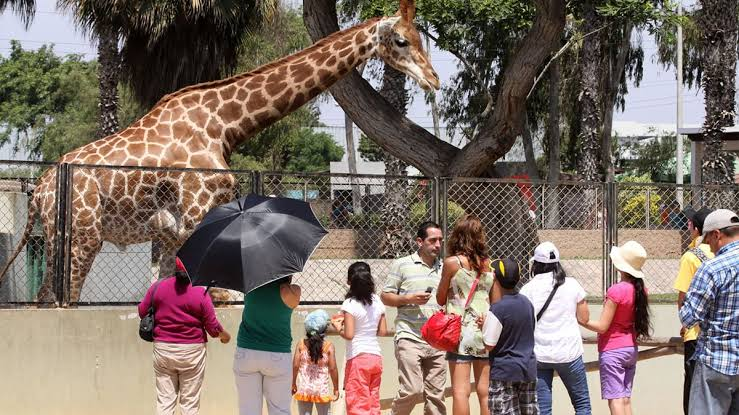

In [3]:
from PIL import Image

image = Image.open("../data/zoologico.jpeg").convert("RGB")
display(image)

In [4]:
import imageio

In [ ]:
generator = torch.manual_seed(42)
frames = modelo(image, decode_chunk_size=1, generator=generator)
output_path = "../data/zoo_video.mp4"

imageio.mimsave(output_path, frames, fps=1)

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
 20%|██        | 5/25 [00:52<03:39, 10.96s/it]

In [ ]:
from IPython.display import Video

Video(output_path, embed=True)